# Animal Multi-Day Behavior Workflow

This notebook collects behavioral sessions for a single animal, converts Unity JSON logs to HDF5 files, and assembles multi-day trial summaries with rolling accuracy metrics. Adjust the parameters below and run the notebook top-to-bottom.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "behavioral_analysis").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate repository root starting from {start}"
    )


repo_root = find_repo_root(Path.cwd())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Repository root: {repo_root}")
print(f"Added to sys.path: {src_path}")

Repository root: /groups/spruston/home/moharb/DELTA_Behavior
Added to sys.path: /groups/spruston/home/moharb/DELTA_Behavior/src


In [2]:
# Parameters
ANIMAL_ID = "BM33"  # Update with the animal identifier of interest
SEARCH_ROOT = Path("/nearline/spruston/Boaz/Mesoscope") / ANIMAL_ID  # Directory to search for JSON logs (recursive)
OUTPUT_HDF5_DIR = repo_root / "outputs" / "hdf5" / ANIMAL_ID
ROLLING_WINDOW = 20  # Number of trials in the running accuracy window
OVERWRITE_EXISTING = False  # Set True to regenerate HDF5 files even if they exist
SKIP_FAILED_SESSIONS = True  # Continue when a JSON log is missing required events

In [3]:
import pandas as pd
from behavioral_analysis.analysis import collect_json_logs

json_paths = collect_json_logs(ANIMAL_ID, SEARCH_ROOT)
if not json_paths:
    raise FileNotFoundError(f"No JSON logs for {ANIMAL_ID} under {SEARCH_ROOT}")

json_summary = pd.DataFrame({
    "json_path": [path.as_posix() for path in json_paths]
})
json_summary

,json_path
0,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
1,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
2,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
3,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
4,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
5,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
6,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
7,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
8,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...
9,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...


In [4]:
from behavioral_analysis.analysis import convert_json_sessions

conversion_result = convert_json_sessions(
    json_paths,
    animal_id=ANIMAL_ID,
    output_dir=OUTPUT_HDF5_DIR,
    overwrite=OVERWRITE_EXISTING,
    verbose=True,
    skip_failures=SKIP_FAILED_SESSIONS,
    return_failures=True,
)

if isinstance(conversion_result, tuple):
    conversions, conversion_failures = conversion_result
else:  # Backward compatibility
    conversions = conversion_result
    conversion_failures = []

if not conversions:
    raise RuntimeError("No sessions were successfully converted; adjust SEARCH_ROOT or ensure logs contain cue data.")

conversion_summary = pd.DataFrame({
    "session_order": range(1, len(conversions) + 1),
    "session_label": [c.session_label for c in conversions],
    "session_date": [c.session_date for c in conversions],
    "session_number": [c.session_number for c in conversions],
    "json_path": [c.json_path.as_posix() for c in conversions],
    "hdf5_path": [c.hdf5_path.as_posix() for c in conversions],
}).sort_values("session_date").reset_index(drop=True)
conversion_summary

Processing JSON data with global position: /nearline/spruston/Boaz/Mesoscope/BM33/Log BM33 2025-07-09 session 1.json
Step 1: Parsing JSON file
Parsing file: /nearline/spruston/Boaz/Mesoscope/BM33/Log BM33 2025-07-09 session 1.json
File size: 6.07 MB
Processed 10000 events...
Processed 20000 events...
Processed 30000 events...
Processed 40000 events...
Processed 50000 events...
Processed 60000 events...

Processing completed in 0.24 seconds
Total events: 63934

Event counts by type:
  Position: 42645
  Log: 21250
  Reward: 37
  Info: 1
  Linear Controller Settings: 1
Step 2: Extracting events to DataFrames
Extracting events by type...
Event extraction completed in 0.12 seconds
Extracted 5 event types

Event types summary:
  Info: 1 events, 4 columns: time, session_time, project, scene
  Linear Controller Settings: 1 events, 6 columns: time, name, isActive, loopPath, gain, inputSmooth
  Position: 42645 events, 4 columns: time, name, position, heading
  Log: 21250 events, 3 columns: time,

Processed 120000 events...
Processed 130000 events...
Processed 140000 events...
Processed 150000 events...
Processed 160000 events...
Processed 170000 events...
Processed 180000 events...
Processed 190000 events...
Processed 200000 events...
Processed 210000 events...
Processed 220000 events...
Processed 230000 events...
Processed 240000 events...
Processed 250000 events...
Processed 260000 events...
Processed 270000 events...
Processed 280000 events...
Processed 290000 events...
Processed 300000 events...
Processed 310000 events...
Processed 320000 events...
Processed 330000 events...

Processing completed in 1.95 seconds
Total events: 333959

Event counts by type:
  Position: 220912
  Log: 112768
  Reward: 277
  Info: 1
  Linear Controller Settings: 1
Step 2: Extracting events to DataFrames
Extracting events by type...
Event extraction completed in 0.44 seconds
Extracted 5 event types

Event types summary:
  Info: 1 events, 4 columns: time, session_time, project, scene
  Linear Cont

/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['name', 'gain'], dtype='object')]

  store[f'events/{safe_event_type}'] = df


  Saved Path Position data (180453 rows)
  Saved Log data (90524 rows)
  Saved Lick data (2114 rows)
  Saved Cue State data (207 rows)
  Saved Start Period data (1 rows)
  Saved Reward data (95 rows)
  Saved Cue Result data (197 rows)
  Saved Corridor_Info data (20 rows)
  Saved Lick_Position data (2114 rows)
  Saved Trials data (197 rows)
  Saved Lick_Cue_Window data (1591 rows)
  Saved metadata
Successfully saved all data to /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM33/Log BM33 2025-08-04 session 1.h5 in 0.61 seconds
Processing completed in 7.31 seconds
Output file: /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM33/Log BM33 2025-08-04 session 1.h5
Processing JSON data with global position: /nearline/spruston/Boaz/Mesoscope/BM33/Log BM33 2025-08-04 session 2.json
Step 1: Parsing JSON file
Parsing file: /nearline/spruston/Boaz/Mesoscope/BM33/Log BM33 2025-08-04 session 2.json
File size: 25.89 MB


/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:74: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  store['metadata'] = pd.Series(metadata)


...

  Saved Cue Result data (216 rows)
  Saved Reward data (107 rows)
  Saved Idle! data (2 rows)
  Saved End Period data (1 rows)
  Saved Corridor_Info data (22 rows)
  Saved Lick_Position data (3096 rows)
  Saved Trials data (216 rows)
  Saved Lick_Cue_Window data (2322 rows)
  Saved metadata
Successfully saved all data to /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM33/Log BM33 2025-08-05 session 1.h5 in 0.31 seconds
Processing completed in 7.67 seconds
Output file: /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM33/Log BM33 2025-08-05 session 1.h5
Processing JSON data with global position: /nearline/spruston/Boaz/Mesoscope/BM33/Log BM33 2025-08-05 session 2.json
Step 1: Parsing JSON file
Parsing file: /nearline/spruston/Boaz/Mesoscope/BM33/Log BM33 2025-08-05 session 2.json
File size: 22.91 MB


/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:74: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  store['metadata'] = pd.Series(metadata)


Processed 10000 events...
Processed 20000 events...
Processed 30000 events...
Processed 40000 events...
Processed 50000 events...
Processed 60000 events...
Processed 70000 events...
Processed 80000 events...
Processed 90000 events...
Processed 100000 events...
Processed 110000 events...
Processed 120000 events...
Processed 130000 events...
Processed 140000 events...
Processed 150000 events...
Processed 160000 events...
Processed 170000 events...
Processed 180000 events...
Processed 190000 events...
Processed 200000 events...
Processed 210000 events...
Processed 220000 events...
Processed 230000 events...
Processed 240000 events...

Processing completed in 1.40 seconds
Total events: 242565

Event counts by type:
  Position: 96313
  Path Position: 96312
  Log: 48157
  Lick: 1445
  Cue State: 139
  Cue Result: 129
  Reward: 67
  Info: 1
  Linear Controller Settings: 1
  Start Period: 1
Step 2: Extracting events to DataFrames
Extracting events by type...
Event extraction completed in 0.32 

/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['name', 'gain'], dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:74: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  store['metadata'] = pd.Series(metadata)


,session_order,session_label,session_date,session_number,json_path,hdf5_path
0,1,2025-07-14 - Log BM33 2025-07-14 session 1,2025-07-14,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
1,2,2025-07-14 - Log BM33 2025-07-14 session 3,2025-07-14,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
2,3,2025-07-15 - Log BM33 2025-07-15 session 1,2025-07-15,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
3,4,2025-07-16 - Log BM33 2025-07-16 session 1,2025-07-16,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
4,5,2025-07-17 - Log BM33 2025-07-17 session 1,2025-07-17,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
5,6,2025-07-17 - Log BM33 2025-07-17 session 2,2025-07-17,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
6,7,2025-07-18 - Log BM33 2025-07-18 session 1,2025-07-18,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
7,8,2025-07-18 - Log BM33 2025-07-18 session 2,2025-07-18,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
8,9,2025-07-21 - Log BM33 2025-07-21 session 1,2025-07-21,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
9,10,2025-07-22 - Log BM33 2025-07-22 session 2,2025-07-22,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...


In [5]:
if conversion_failures:
    failure_summary = pd.DataFrame([
        {"json_path": failure.json_path.as_posix(), "error": failure.error}
        for failure in conversion_failures
    ])
    display(failure_summary)
else:
    print("No conversion failures.")

,json_path,error
0,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,ValueError: Input data must contain Cue State ...
1,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,ValueError: Input data must contain Cue State ...
2,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,ValueError: Input data must contain Cue State ...
3,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,ValueError: Input data must contain Cue State ...


In [6]:
from behavioral_analysis.analysis import prepare_multi_day_trials

multi_day = prepare_multi_day_trials(conversions, rolling_window=ROLLING_WINDOW)
multi_day.session_summary


,session_order,session_date,session_label,session_number,source_json,source_hdf5,n_trials,accuracy_pct,hit_rate_pct,fa_rate_pct
0,1,2025-07-14,2025-07-14 - Log BM33 2025-07-14 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,104,53.846154,100.000000,85.714286
1,2,2025-07-14,2025-07-14 - Log BM33 2025-07-14 session 3,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,32,46.875000,100.000000,94.444444
2,3,2025-07-15,2025-07-15 - Log BM33 2025-07-15 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,99,56.565657,100.000000,86.000000
3,4,2025-07-16,2025-07-16 - Log BM33 2025-07-16 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,138,52.898551,86.301370,84.615385
4,5,2025-07-17,2025-07-17 - Log BM33 2025-07-17 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,169,52.662722,77.647059,72.619048
5,6,2025-07-17,2025-07-17 - Log BM33 2025-07-17 session 2,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,208,57.211538,86.086957,78.494624
6,7,2025-07-18,2025-07-18 - Log BM33 2025-07-18 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,5,80.000000,100.000000,33.333333
7,8,2025-07-18,2025-07-18 - Log BM33 2025-07-18 session 2,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,55,65.454545,100.000000,59.375000
8,9,2025-07-21,2025-07-21 - Log BM33 2025-07-21 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,101,58.415842,87.755102,69.230769
9,10,2025-07-22,2025-07-22 - Log BM33 2025-07-22 session 2,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,146,45.890411,64.383562,72.602740


In [7]:
daily_accuracy = (
    multi_day.trials.groupby("session_date")
    ["correct"]
    .mean()
    .mul(100.0)
    .reset_index(name="accuracy_pct")
)
daily_accuracy

,session_date,accuracy_pct
0,2025-07-14,52.205882
1,2025-07-15,56.565657
2,2025-07-16,52.898551
3,2025-07-17,55.172414
4,2025-07-18,66.666667
5,2025-07-21,58.415842
6,2025-07-22,50.000000
7,2025-07-23,49.814126
8,2025-07-24,56.603774
9,2025-07-25,55.231788


In [8]:
multi_day.trials.head()

,trial_id,corridor,cue_id_in_corridor,cue_type,is_rewarding,cue_position,cue_position_cm,global_position_cm,cue_onset_ms,cue_outcome_ms,...,licks_in_window,trial_in_session,session_order,session_date,session_label,session_number,source_json,source_hdf5,trial_index_global,rolling_accuracy_pct
0,0,0,0,Non-rewarding,False,3005,30.05,30.05,10974.68,40696.36,...,0,1,1,2025-07-14,2025-07-14 - Log BM33 2025-07-14 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,1,100.0
1,1,0,1,Rewarding,True,7734,77.34,77.34,10975.44,43147.69,...,16,2,1,2025-07-14,2025-07-14 - Log BM33 2025-07-14 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2,100.0
2,2,0,2,Non-rewarding,False,12443,124.43,124.43,10975.82,58628.19,...,0,3,1,2025-07-14,2025-07-14 - Log BM33 2025-07-14 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,3,100.0
3,3,0,3,Non-rewarding,False,16860,168.60,168.60,10976.20,85416.62,...,1,4,1,2025-07-14,2025-07-14 - Log BM33 2025-07-14 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,4,75.0
4,4,0,4,Non-rewarding,False,20831,208.31,208.31,10976.56,88403.62,...,2,5,1,2025-07-14,2025-07-14 - Log BM33 2025-07-14 session 1,None,/nearline/spruston/Boaz/Mesoscope/BM33/Log BM3...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,5,60.0


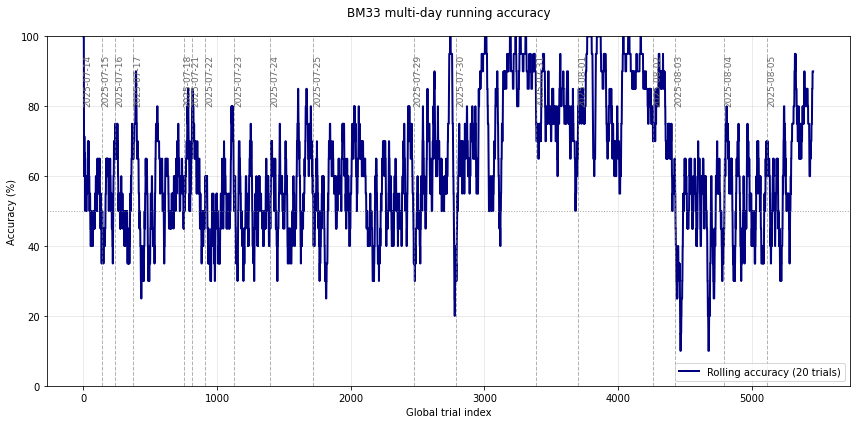

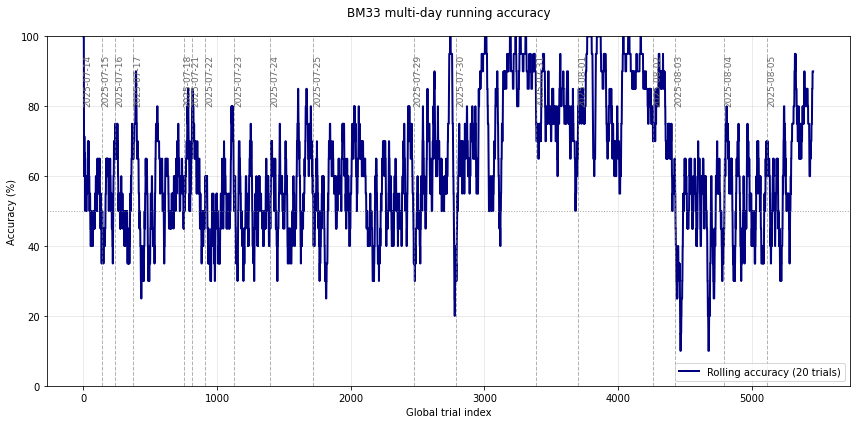

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    multi_day.trials["trial_index_global"],
    multi_day.trials["rolling_accuracy_pct"],
    color="navy",
    linewidth=2,
    label=f"Rolling accuracy ({ROLLING_WINDOW} trials)",
)
ax.axhline(50, color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax.set_xlabel("Global trial index")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

for transition in multi_day.day_transitions[1:]:
    ax.axvline(
        transition.first_trial_index - 0.5,
        linestyle="--",
        color="gray",
        linewidth=1,
        alpha=0.6,
    )

ymin, ymax = ax.get_ylim()
label_y = ymax - (ymax - ymin) * 0.05
for idx, transition in enumerate(multi_day.day_transitions, start=1):
    ax.text(
        transition.first_trial_index,
        label_y,
        transition.session_date.isoformat(),
        rotation=90,
        va="top",
        ha="left",
        fontsize=9,
        color="dimgray",
    )

ax.set_title(f"{ANIMAL_ID} multi-day running accuracy", pad=20)
ax.legend(loc="lower right")
fig.tight_layout()
fig